In [1]:
from reviews_over_time import plot_reviews_over_time
from stats_tests import run_tests

Completed filter + merge of metadata.


/Users/saathvikdirisala/Documents/ece143/final_project/AmazonReviewsDataAnalysis/reviews_over_time/reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


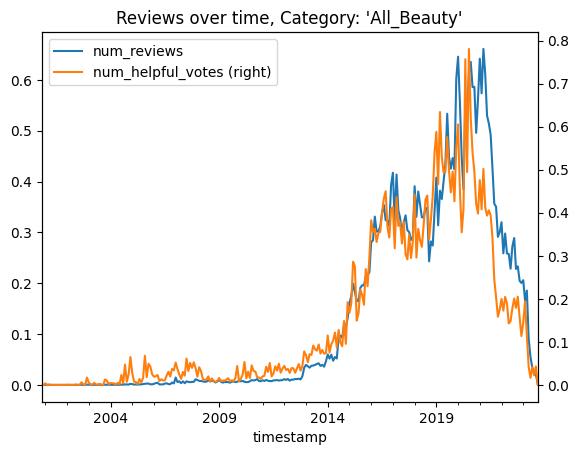

In [2]:
ax = plot_reviews_over_time("All_Beauty")

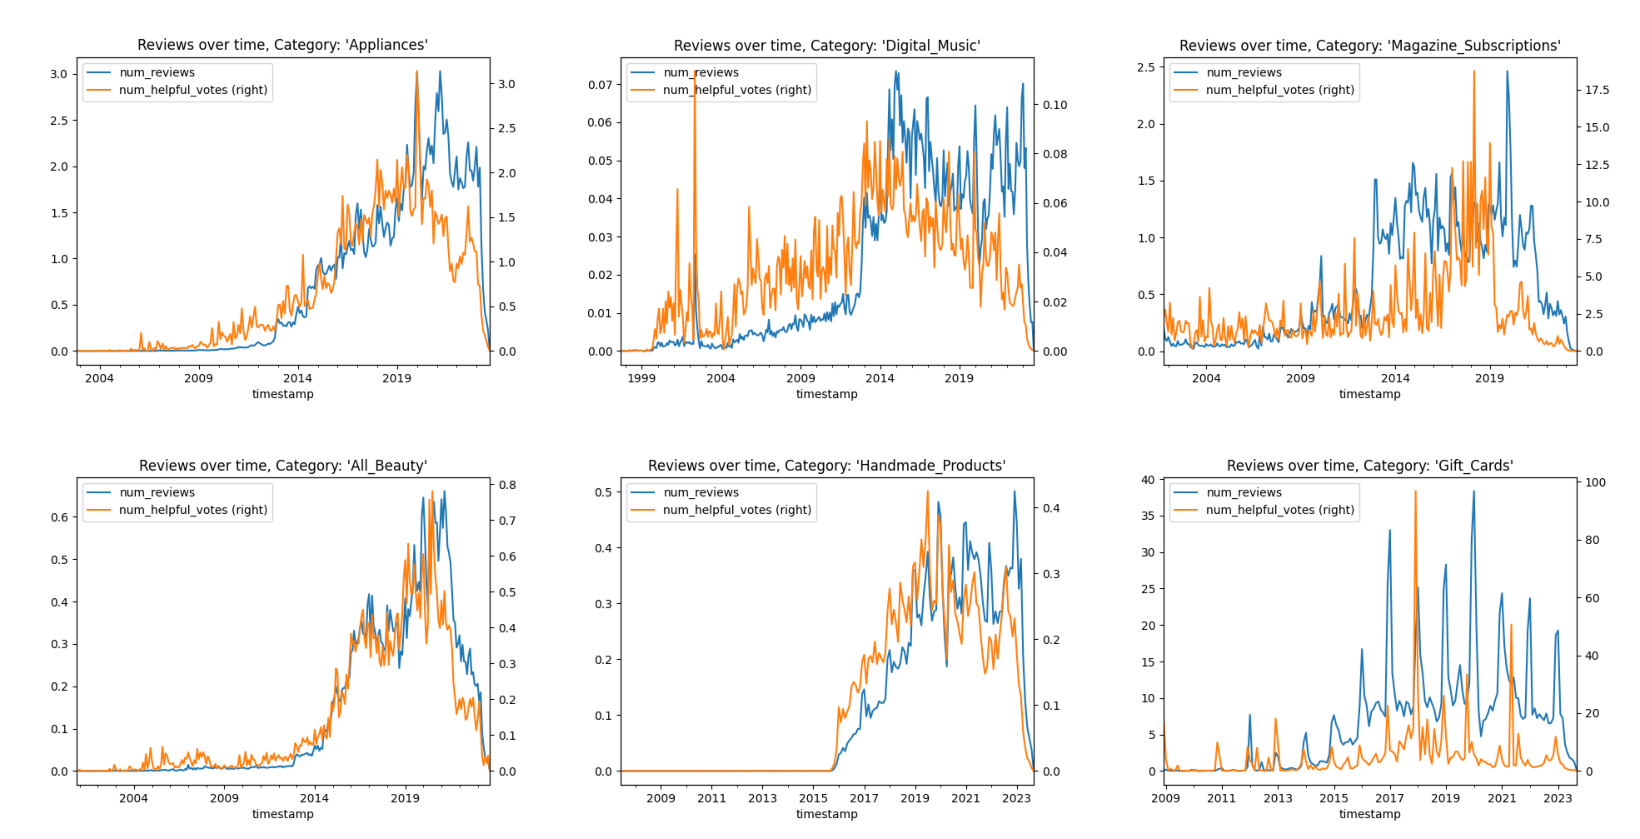

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

contents = os.listdir("plots/")
contents.remove("categories_reviews.png")
image_files = list(map(lambda x: "plots/" + x, contents))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = mpimg.imread(image_files[i])
    ax.imshow(img)
    ax.axis('off')

plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3)

plt.savefig("plots/categories_reviews.png")
plt.show()


### Observations:
- It seems like a spike in reviews is almost always preceded by a spike in helpful votes
- Most of the categories seem to have a similar trend shape, with slow growth in the beginning followed by a sharp uptick in "popularity"

### Next Step:
- Perhaps, we can see if a lagged helpful votes variable actually is predictive of number of reviews or not

In [3]:
line1 = ax.get_lines()[0]
line2 = ax.right_ax.get_lines()[0]

time = line1.get_xdata()
num_reviews = line1.get_ydata()
helpful_votes = line2.get_ydata()

len(time), len(num_reviews), len(helpful_votes)

(275, 275, 275)

Generating correlation plot...
Computing OLS...
                            OLS Regression Results                            
Dep. Variable:                reviews   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     4219.
Date:                Tue, 24 Feb 2026   Prob (F-statistic):          6.37e-205
Time:                        18:04:13   Log-Likelihood:                 552.12
No. Observations:                 274   AIC:                            -1098.
Df Residuals:                     271   BIC:                            -1087.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------


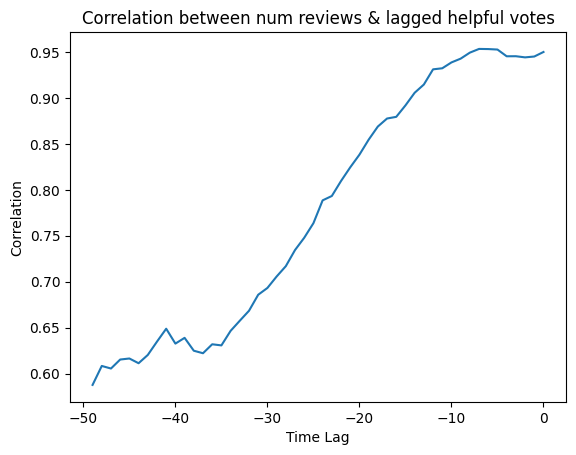

In [4]:
run_tests(time, num_reviews, helpful_votes)